# NYC Robustness Checks and Boston External-Control Stress Test

This notebook keeps the 263-route propensity-score common-support universe from the main DiD notebook and provides:

1. **NYC treatment-definition robustness** across the GeoJSON any-intersection rule and stricter CBD-share thresholds.
2. **NYC sample robustness** across weekday/all-day and Peak/Off-Peak samples.
3. **Boston external-control stress test**, interpreted descriptively because Boston fails the current pretrend diagnostics.

The old official CBD-source union is audited but not re-estimated: within this common-support sample its treatment flags are identical to the GeoJSON any-intersection flags.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from nyc_common_support import compute_common_support
PROCESSED = ROOT / "data" / "processed"
TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"

NYC_PANEL = PROCESSED / "nyc_did_panel_geojson_intersection.csv"
NYC_ROBUSTNESS = TABLES / "nyc_treatment_definition_robustness.csv"
BOSTON_PANEL = PROCESSED / "boston_bus_speeds_monthly.csv"
BOSTON_COMPARISON_OUTPUT = TABLES / "nyc_vs_boston_external_control_robustness.csv"
OFFICIAL_EQUIVALENCE = TABLES / "nyc_old_official_treatment_equivalence_audit.csv"

POLICY_MONTH = pd.Timestamp("2025-01-01")
ANALYSIS_START = pd.Timestamp("2023-08-01")
ANALYSIS_END = pd.Timestamp("2026-05-01")

pd.set_option("display.max_columns", 80)
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

## 1. NYC Treatment-Definition Robustness

All NYC robustness estimates use the same propensity-score common-support route universe as the main notebook: 263 routes, including 81 routes treated by the main GeoJSON any-intersection rule and 182 controls. Threshold definitions are stricter robustness checks based on the maximum route-shape share inside the CBD.

In [2]:
robustness = pd.read_csv(NYC_ROBUSTNESS)
official_equivalence = pd.read_csv(OFFICIAL_EQUIVALENCE)
display(official_equivalence)
robustness.head(10)

,analysis_routes,geojson_treated_routes,old_official_treated_routes,mismatched_routes,identical_in_common_support_sample,interpretation
0,263,81,81,0,True,Mechanical duplicate; excluded from robustness...


,sample,treatment_column,treatment_definition,common_support_sample,estimate_mph,std_error,p_value,ci_low,ci_high,rows,routes,treated_routes,control_routes
0,weekday_all_periods,any_intersection,GeoJSON any policy-date route shape intersects...,True,0.141398,0.047682,0.003022,0.047942,0.234854,17815,263,81,182
1,weekday_all_periods,max_share_ge_05pct,GeoJSON max shape share in CBD >= 5%,True,0.142006,0.048691,0.003540,0.046571,0.237441,17815,263,79,184
2,weekday_all_periods,max_share_ge_10pct,GeoJSON max shape share in CBD >= 10%,True,0.158684,0.050176,0.001564,0.060339,0.257028,17815,263,75,188
3,weekday_all_periods,max_share_ge_25pct,GeoJSON max shape share in CBD >= 25%,True,0.064760,0.072776,0.373550,-0.077882,0.207401,17815,263,33,230
4,weekday_all_periods,max_share_ge_50pct,GeoJSON max shape share in CBD >= 50%,True,0.016519,0.024378,0.498017,-0.031261,0.064299,17815,263,22,241
5,weekday_all_periods,max_share_ge_80pct,GeoJSON max shape share in CBD >= 80%,True,0.030505,0.026635,0.252082,-0.021700,0.082710,17815,263,15,248
6,all_day_types_all_periods,any_intersection,GeoJSON any policy-date route shape intersects...,True,0.132423,0.044453,0.002892,0.045296,0.219550,33827,263,81,182
7,all_day_types_all_periods,max_share_ge_05pct,GeoJSON max shape share in CBD >= 5%,True,0.135218,0.045493,0.002956,0.046052,0.224384,33827,263,79,184
8,all_day_types_all_periods,max_share_ge_10pct,GeoJSON max shape share in CBD >= 10%,True,0.152983,0.045896,0.000858,0.063027,0.242939,33827,263,75,188
9,all_day_types_all_periods,max_share_ge_25pct,GeoJSON max shape share in CBD >= 25%,True,0.104971,0.066341,0.113584,-0.025058,0.234999,33827,263,33,230


In [3]:
weekday = robustness[robustness["sample"].eq("weekday_all_periods")].copy()
weekday["estimate_label"] = weekday["treatment_column"].map({
    "any_intersection": "Any intersection",
    "max_share_ge_05pct": ">= 5% max share",
    "max_share_ge_10pct": ">= 10% max share",
    "max_share_ge_25pct": ">= 25% max share",
    "max_share_ge_50pct": ">= 50% max share",
    "max_share_ge_80pct": ">= 80% max share",
})
weekday[["estimate_label", "treated_routes", "control_routes", "estimate_mph", "std_error", "p_value", "ci_low", "ci_high"]]

,estimate_label,treated_routes,control_routes,estimate_mph,std_error,p_value,ci_low,ci_high
0,Any intersection,81,182,0.141398,0.047682,0.003022,0.047942,0.234854
1,>= 5% max share,79,184,0.142006,0.048691,0.003540,0.046571,0.237441
2,>= 10% max share,75,188,0.158684,0.050176,0.001564,0.060339,0.257028
3,>= 25% max share,33,230,0.064760,0.072776,0.373550,-0.077882,0.207401
4,>= 50% max share,22,241,0.016519,0.024378,0.498017,-0.031261,0.064299
5,>= 80% max share,15,248,0.030505,0.026635,0.252082,-0.021700,0.082710


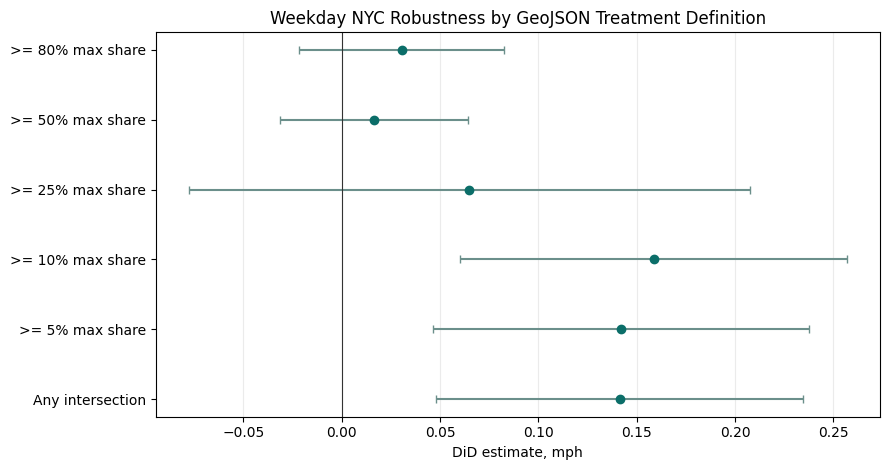

In [4]:
plot_df = weekday[weekday["treatment_column"].ne("old_official_source_union")].copy()
plot_df = plot_df.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(plot_df))
ax.errorbar(
    plot_df["estimate_mph"],
    y,
    xerr=[plot_df["estimate_mph"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["estimate_mph"]],
    fmt="o",
    color="#0b6e69",
    ecolor="#6b8f8b",
    capsize=3,
)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["estimate_label"])
ax.set_xlabel("DiD estimate, mph")
ax.set_title("Weekday NYC Robustness by GeoJSON Treatment Definition")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

**Takeaway.** On the common-support sample, the main any-intersection estimate remains positive. It is stable at the 5% threshold and slightly larger at 10%, then attenuates under stricter definitions that keep only routes with a large share inside the CBD. The old official union is not shown as a robustness estimate because its route flags are identical to any intersection in this sample.

In [5]:
sample_summary = robustness.pivot_table(
    index="treatment_column",
    columns="sample",
    values="estimate_mph",
    aggfunc="first",
)
sample_summary

sample,all_day_types_all_periods,weekday_all_periods,weekday_off_peak,weekday_peak
treatment_column,,,,
any_intersection,0.132423,0.141398,0.119687,0.162311
max_share_ge_05pct,0.135218,0.142006,0.120764,0.162439
max_share_ge_10pct,0.152983,0.158684,0.135868,0.180675
max_share_ge_25pct,0.104971,0.064760,0.055094,0.074190
max_share_ge_50pct,0.055582,0.016519,0.026652,0.006140
max_share_ge_80pct,0.076194,0.030505,0.047943,0.012828


## 2. Boston External-Control Stress Test

This section asks whether the NYC CBD speed gain is still visible when the comparison group is Boston MBTA bus routes rather than NYC non-CBD routes.

Construction choices:

- NYC sample: CBD-treated NYC routes only, weekday rows, August 2023 through May 2026.
- Boston sample: all processed MBTA routes, weekday rows, same months.
- Unit of observation: route-month-period after aggregating duplicate rows within each route/month/period.
- Model: `average_speed ~ did + route fixed effects + month fixed effects + period fixed effects`, clustered by route/unit.

This is deliberately labeled a stress test because Boston is an external city with different measurement and network structure.

In [6]:
def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")


def build_nyc_cbd_external_panel():
    nyc = pd.read_csv(NYC_PANEL)
    nyc["month"] = pd.to_datetime(nyc["month"])
    support_audit = compute_common_support(nyc)
    common_support_routes = set(
        support_audit.loc[support_audit["in_common_support"], "route_id"]
    )
    nyc = nyc[
        nyc["month"].between(ANALYSIS_START, ANALYSIS_END)
        & nyc["route_id"].isin(common_support_routes)
        & nyc["day_type"].astype(str).eq("1")
        & nyc["cbd_route"].astype(bool)
    ].copy()
    nyc["total_mileage"] = clean_numeric(nyc["total_mileage"])
    nyc["total_operating_time"] = clean_numeric(nyc["total_operating_time"])
    grouped = (
        nyc.groupby(["month", "route_id", "period"], as_index=False)
        .agg(
            total_distance_miles=("total_mileage", "sum"),
            total_runtime_hours=("total_operating_time", "sum"),
        )
    )
    grouped["average_speed"] = grouped["total_distance_miles"] / grouped["total_runtime_hours"]
    grouped["unit_id"] = "NYC_CBD_" + grouped["route_id"].astype(str)
    grouped["city_group"] = "NYC CBD routes"
    grouped["treated"] = True
    grouped["post"] = grouped["month"].ge(POLICY_MONTH)
    return grouped


def build_boston_external_panel():
    boston = pd.read_csv(BOSTON_PANEL)
    boston["month"] = pd.to_datetime(boston["month"])
    boston = boston[
        boston["month"].between(ANALYSIS_START, ANALYSIS_END)
        & boston["day_type"].eq("Weekday")
    ].copy()
    grouped = (
        boston.groupby(["month", "route_id", "period"], as_index=False)
        .agg(
            total_distance_miles=("total_distance_miles", "sum"),
            total_runtime_hours=("total_runtime_hours", "sum"),
        )
    )
    grouped["average_speed"] = grouped["total_distance_miles"] / grouped["total_runtime_hours"]
    grouped["unit_id"] = "BOSTON_" + grouped["route_id"].astype(str)
    grouped["city_group"] = "Boston routes"
    grouped["treated"] = False
    grouped["post"] = grouped["month"].ge(POLICY_MONTH)
    return grouped

nyc_external = build_nyc_cbd_external_panel()
boston_external = build_boston_external_panel()
external_panel = pd.concat([nyc_external, boston_external], ignore_index=True)
external_panel = external_panel.dropna(subset=["average_speed", "total_runtime_hours"])
external_panel["did"] = external_panel["treated"].astype(int) * external_panel["post"].astype(int)

external_panel.groupby("city_group").agg(
    rows=("average_speed", "size"),
    routes=("unit_id", "nunique"),
    months=("month", "nunique"),
    mean_speed=("average_speed", "mean"),
    total_distance_miles=("total_distance_miles", "sum"),
)

,rows,routes,months,mean_speed,total_distance_miles
city_group,,,,,
Boston routes,9253,143,34,11.889809,3.832088e+07
NYC CBD routes,5414,81,34,9.378703,3.961956e+07


In [7]:
external_model = smf.ols(
    "average_speed ~ did + C(unit_id) + C(month) + C(period)",
    data=external_panel,
).fit(cov_type="cluster", cov_kwds={"groups": external_panel["unit_id"]})

external_result = pd.DataFrame([
    {
        "comparison": "NYC CBD routes vs Boston routes",
        "sample": "weekday_all_periods",
        "estimate_mph": external_model.params["did"],
        "std_error": external_model.bse["did"],
        "p_value": external_model.pvalues["did"],
        "ci_low": external_model.params["did"] - 1.96 * external_model.bse["did"],
        "ci_high": external_model.params["did"] + 1.96 * external_model.bse["did"],
        "rows": len(external_panel),
        "units": external_panel["unit_id"].nunique(),
        "nyc_cbd_units": nyc_external["unit_id"].nunique(),
        "boston_units": boston_external["unit_id"].nunique(),
    }
])
external_result.to_csv(BOSTON_COMPARISON_OUTPUT, index=False)
external_result

,comparison,sample,estimate_mph,std_error,p_value,ci_low,ci_high,rows,units,nyc_cbd_units,boston_units
0,NYC CBD routes vs Boston routes,weekday_all_periods,0.462039,0.061839,7.922708e-14,0.340834,0.583244,14667,224,81,143


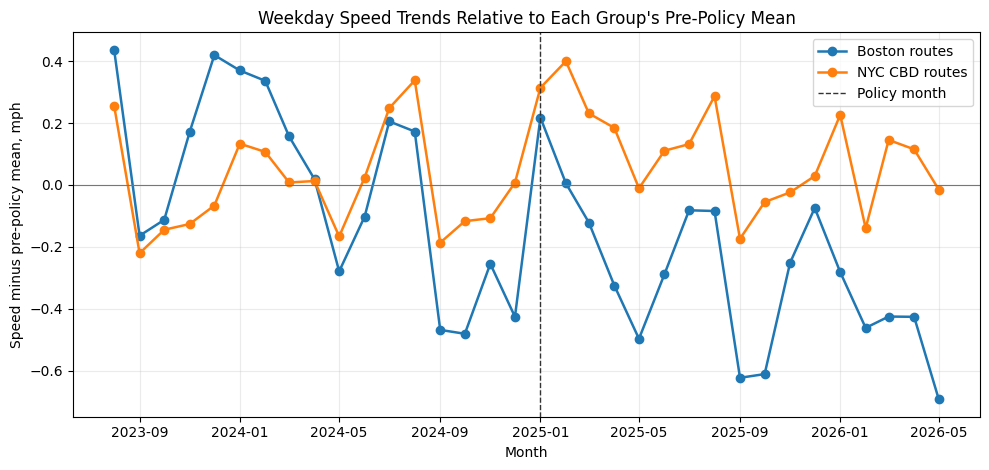

In [8]:
trend = (
    external_panel.groupby(["city_group", "month"], as_index=False)
    .agg(
        total_distance_miles=("total_distance_miles", "sum"),
        total_runtime_hours=("total_runtime_hours", "sum"),
    )
)
trend["average_speed"] = trend["total_distance_miles"] / trend["total_runtime_hours"]
pre_mean = trend[trend["month"].lt(POLICY_MONTH)].groupby("city_group")["average_speed"].mean()
trend["indexed_speed"] = trend.apply(lambda row: row["average_speed"] - pre_mean.loc[row["city_group"]], axis=1)

fig, ax = plt.subplots(figsize=(10, 4.8))
for group, group_df in trend.groupby("city_group"):
    ax.plot(group_df["month"], group_df["indexed_speed"], marker="o", linewidth=1.8, label=group)
ax.axvline(POLICY_MONTH, color="#333333", linestyle="--", linewidth=1, label="Policy month")
ax.axhline(0, color="#777777", linewidth=0.8)
ax.set_title("Weekday Speed Trends Relative to Each Group's Pre-Policy Mean")
ax.set_ylabel("Speed minus pre-policy mean, mph")
ax.set_xlabel("Month")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

**Boston stress-test interpretation.** If the Boston comparison estimate has the same sign and broad magnitude as the main NYC control-route DiD, it gives some reassurance that the post-policy NYC CBD speed increase is not simply an artifact of using NYC non-CBD controls. If it differs sharply, that does not automatically invalidate the main design, because Boston is not a treated/control contrast within the same transit system.

In [9]:
print(f"Saved Boston external-control result to: {BOSTON_COMPARISON_OUTPUT.relative_to(ROOT)}")
print(f"Saved NYC threshold robustness table at: {NYC_ROBUSTNESS.relative_to(ROOT)}")

Saved Boston external-control result to: outputs\tables\nyc_vs_boston_external_control_robustness.csv
Saved NYC threshold robustness table at: outputs\tables\nyc_treatment_definition_robustness.csv


## Strict Peak and Off-Peak Treatment-Definition Robustness

The focused check below holds service period strictly to Peak or Off-Peak weekday observations while retaining the main notebook's common-support route universe. Each row uses route fixed effects, month fixed effects, and route-clustered standard errors. The old official union is omitted because it duplicates the any-intersection route flags exactly.

In [10]:
strict_periods = robustness[robustness["sample"].isin(["weekday_peak", "weekday_off_peak"])].copy()
strict_periods["estimate_label"] = strict_periods["treatment_column"].map({
    "any_intersection": "Any intersection",
    "max_share_ge_05pct": ">= 5% max share",
    "max_share_ge_10pct": ">= 10% max share",
    "max_share_ge_25pct": ">= 25% max share",
    "max_share_ge_50pct": ">= 50% max share",
    "max_share_ge_80pct": ">= 80% max share",
})
strict_periods[["sample", "estimate_label", "treated_routes", "control_routes", "estimate_mph", "std_error", "p_value", "ci_low", "ci_high"]]

,sample,estimate_label,treated_routes,control_routes,estimate_mph,std_error,p_value,ci_low,ci_high
12,weekday_peak,Any intersection,81,182,0.162311,0.045430,0.000353,0.073268,0.251354
13,weekday_peak,>= 5% max share,79,184,0.162439,0.046379,0.000461,0.071537,0.253342
14,weekday_peak,>= 10% max share,75,188,0.180675,0.047659,0.000150,0.087264,0.274087
15,weekday_peak,>= 25% max share,33,230,0.074190,0.065942,0.260560,-0.055057,0.203437
16,weekday_peak,>= 50% max share,22,241,0.006140,0.024748,0.804061,-0.042366,0.054646
17,weekday_peak,>= 80% max share,15,248,0.012828,0.028074,0.647730,-0.042198,0.067853
18,weekday_off_peak,Any intersection,81,182,0.119687,0.054410,0.027827,0.013043,0.226331
19,weekday_off_peak,>= 5% max share,79,184,0.120764,0.055584,0.029808,0.011819,0.229709
20,weekday_off_peak,>= 10% max share,75,188,0.135868,0.057445,0.018021,0.023276,0.248460
21,weekday_off_peak,>= 25% max share,33,230,0.055094,0.084002,0.511911,-0.109550,0.219739


### Current run: strict-period conclusion

On the common-support sample, the any-intersection estimate is **+0.162 mph** in Peak service (p < 0.001) and **+0.120 mph** in Off-Peak service (p = 0.028). The 5% and 10% thresholds produce similar positive estimates in both periods. At the 25%, 50%, and 80% thresholds, estimates are smaller and not statistically distinguishable from zero at conventional levels. The positive result is therefore robust to Peak/Off-Peak sampling and modest threshold changes, but not to definitions that retain only routes with very high CBD shape shares.